In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!kaggle datasets download emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:18<00:00, 36.9MB/s]



In [ ]:
!unzip plantdisease.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: dataset/plantvillage/PlantVillage/Tomato__

In [ ]:
import os

dataset_path = "dataset"  # अपना path डालना

for root, dirs, files in os.walk(dataset_path):
    print(root, "->", len(files), "files")

dataset -> 0 files
dataset/PlantVillage -> 0 files
dataset/PlantVillage/Pepper__bell___healthy -> 1478 files
dataset/PlantVillage/Tomato_Leaf_Mold -> 952 files
dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus -> 3209 files
dataset/PlantVillage/Potato___Late_blight -> 1000 files
dataset/PlantVillage/Tomato_Early_blight -> 1000 files
dataset/PlantVillage/Tomato_Bacterial_spot -> 2127 files
dataset/PlantVillage/Potato___healthy -> 152 files
dataset/PlantVillage/Tomato_Septoria_leaf_spot -> 1771 files
dataset/PlantVillage/Tomato__Tomato_mosaic_virus -> 373 files
dataset/PlantVillage/Tomato__Target_Spot -> 1404 files
dataset/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite -> 1676 files
dataset/PlantVillage/Tomato_healthy -> 1591 files
dataset/PlantVillage/Potato___Early_blight -> 1000 files
dataset/PlantVillage/Tomato_Late_blight -> 1909 files
dataset/PlantVillage/Pepper__bell___Bacterial_spot -> 997 files
dataset/plantvillage -> 0 files
dataset/plantvillage/PlantVillage 

In [ ]:
import os

os.makedirs("dataset_final", exist_ok=True)

In [ ]:
import os
import shutil

source = "./dataset/PlantVillage"

selected_classes = [
    "Tomato_healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Late_blight"
]

destination = "./dataset_final"

for cls in selected_classes:

    src_path = os.path.join(source, cls)
    dst_path = os.path.join(destination, cls)

    if not os.path.exists(dst_path):
        shutil.copytree(src_path, dst_path)

print("✅ Dataset Created Successfully")

✅ Dataset Created Successfully


In [ ]:
import os

for folder in os.listdir("./dataset"):
    count = len(os.listdir(os.path.join("./dataset", folder)))
    print(folder, "->", count)

Tomato_Leaf_Mold -> 952
Tomato_Bacterial_spot -> 2127
Tomato_Septoria_leaf_spot -> 1771
Tomato_healthy -> 1591
Tomato_Late_blight -> 1909


In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
Tesla T4


In [ ]:
import os

for root, dirs, files in os.walk("./dataset"):
    if len(files) > 0:
        print(root)

./dataset/Tomato_Leaf_Mold
./dataset/Tomato_Bacterial_spot
./dataset/Tomato_Septoria_leaf_spot
./dataset/Tomato_healthy
./dataset/Tomato_Late_blight


In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="./dataset",
    transform=transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))
print("Class Mapping:", dataset.class_to_idx)

Classes: ['Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy']
Total Images: 8350
Class Mapping: {'Tomato_Bacterial_spot': 0, 'Tomato_Late_blight': 1, 'Tomato_Leaf_Mold': 2, 'Tomato_Septoria_leaf_spot': 3, 'Tomato_healthy': 4}


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader
from torch.utils.data import random_split

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import json
import os

In [ ]:
CONFIG = {
    "dataset_path": "./dataset",
    "image_size": 224,
    "batch_size": 32,
    "epochs": 15,
    "learning_rate": 1e-4,
    "num_classes": 5,
    "model_name": "treeguard_model.pth",
    "labels_name": "labels.json"
}

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.1,0.1)
    ),

    transforms.ToTensor(),
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),
])

In [ ]:
full_dataset = datasets.ImageFolder(
    root=CONFIG["dataset_path"],
    transform=train_transform
)

print(full_dataset.classes)
print(len(full_dataset))

['Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy']
8350


In [ ]:
class_mapping = {
    idx:name
    for idx,name
    in enumerate(full_dataset.classes)
}

with open(CONFIG["labels_name"],"w") as f:
    json.dump(class_mapping,f)

print(class_mapping)

{0: 'Tomato_Bacterial_spot', 1: 'Tomato_Late_blight', 2: 'Tomato_Leaf_Mold', 3: 'Tomato_Septoria_leaf_spot', 4: 'Tomato_healthy'}


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size,val_size]
)

In [ ]:
val_dataset.dataset.transform = val_transform

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2
)

In [ ]:
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 92.3MB/s]


In [ ]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
model.classifier = nn.Sequential(

    nn.Dropout(0.3),

    nn.Linear(
        model.last_channel,
        CONFIG["num_classes"]
    )
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

In [ ]:
print("Classes:", full_dataset.classes)
print("Total Images:", len(full_dataset))

Classes: ['Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy']
Total Images: 8350


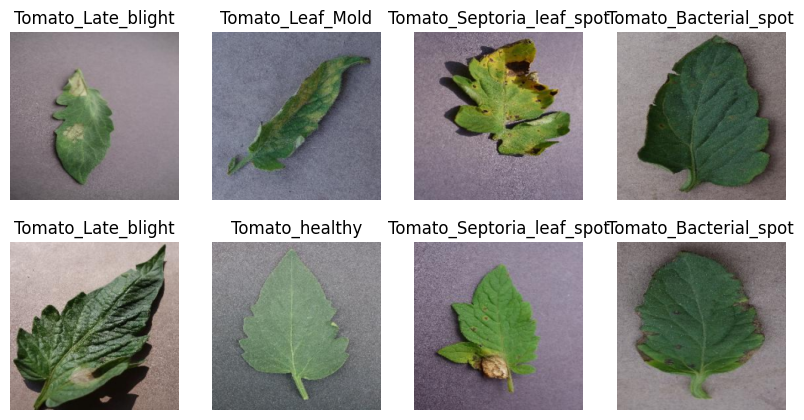

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10,5))

for i, ax in enumerate(axes.flatten()):

    img = images[i].permute(1,2,0)

    ax.imshow(img)

    ax.set_title(
        full_dataset.classes[
            labels[i]
        ]
    )

    ax.axis("off")

plt.show()

In [ ]:
import torch

best_accuracy = 0
patience = 3
counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(CONFIG["epochs"]):

    # -------------------
    # TRAIN
    # -------------------

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # -------------------
    # VALIDATION
    # -------------------

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{CONFIG['epochs']}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

    # -------------------
    # SAVE BEST MODEL
    # -------------------

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(
            model.state_dict(),
            CONFIG["model_name"]
        )

        print(
            f"✅ Best Model Saved: {best_accuracy:.2f}%"
        )

        counter = 0

    else:

        counter += 1

    # -------------------
    # EARLY STOPPING
    # -------------------

    if counter >= patience:

        print("🛑 Early Stopping")

        break

Epoch [1/15] Train Loss: 1.3209 Train Acc: 57.56% Val Loss: 1.0747 Val Acc: 78.44%
✅ Best Model Saved: 78.44%
Epoch [2/15] Train Loss: 0.9649 Train Acc: 80.88% Val Loss: 0.8033 Val Acc: 86.53%
✅ Best Model Saved: 86.53%
Epoch [3/15] Train Loss: 0.7585 Train Acc: 85.96% Val Loss: 0.6491 Val Acc: 90.30%
✅ Best Model Saved: 90.30%
Epoch [4/15] Train Loss: 0.6323 Train Acc: 88.37% Val Loss: 0.5425 Val Acc: 91.80%
✅ Best Model Saved: 91.80%
Epoch [5/15] Train Loss: 0.5474 Train Acc: 90.01% Val Loss: 0.4744 Val Acc: 92.57%
✅ Best Model Saved: 92.57%
Epoch [6/15] Train Loss: 0.4888 Train Acc: 90.09% Val Loss: 0.4185 Val Acc: 93.35%
✅ Best Model Saved: 93.35%
Epoch [7/15] Train Loss: 0.4337 Train Acc: 91.65% Val Loss: 0.3790 Val Acc: 93.41%
✅ Best Model Saved: 93.41%
Epoch [8/15] Train Loss: 0.4031 Train Acc: 91.72% Val Loss: 0.3451 Val Acc: 93.83%
✅ Best Model Saved: 93.83%
Epoch [9/15] Train Loss: 0.3722 Train Acc: 92.10% Val Loss: 0.3169 Val Acc: 94.25%
✅ Best Model Saved: 94.25%
Epoch [10/

In [ ]:
predict_image("/content/dataset/Tomato_Leaf_Mold/00694db7-3327-45e0-b4da-a8bb7ab6a4b7___Crnl_L.Mold 6923.JPG")

NameError: name 'predict_image' is not defined

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(weights=None)

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, 5)
)

model.load_state_dict(
    torch.load(
        "treeguard_model.pth",
        map_location=device
    )
)

model.to(device)

model.eval()

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [ ]:
class_names = [
    "Tomato_Bacterial_spot",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_healthy"
]

In [ ]:
from PIL import Image
from torchvision import transforms
import torch

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image = transform(image)

    image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():

        outputs = model(image)

        probs = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(
            probs,
            dim=1
        )

    disease = class_names[predicted.item()]

    return {
        "disease": disease,
        "confidence": round(
            confidence.item()*100,
            2
        )
    }

In [ ]:
result = predict_image(
    "/content/dataset/Tomato_Leaf_Mold/00694db7-3327-45e0-b4da-a8bb7ab6a4b7___Crnl_L.Mold 6923.JPG"
)

print(result)

{'disease': 'Tomato_Leaf_Mold', 'confidence': 77.85}


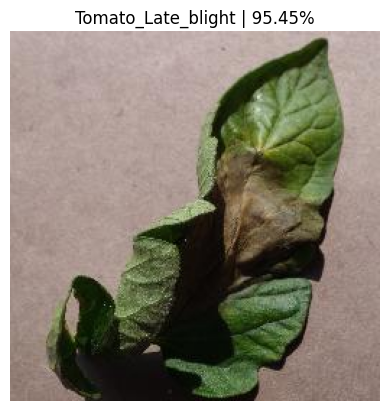

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/dataset/Tomato_Late_blight/0003faa8-4b27-4c65-bf42-6d9e352ca1a5___RS_Late.B 4946.JPG"

result = predict_image(img_path)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")

plt.title(
    f"{result['disease']} | {result['confidence']}%"
)

plt.show()